<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part I · Foundations &nbsp;|&nbsp; Chapter 5</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Levels of Measurement <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:710px;line-height:1.6">Four demos on the NOIR scales, classify variables by level, prove why "twice as hot" is a myth, choose the right average for each level, and see exactly which math each one allows.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

> ### 🎯 What you'll build in this notebook
>
> | # | Demo | Concept |
> |---|------|---------|
> | 1 | Tag every column with its level | **Nominal / Ordinal / Interval / Ratio** |
> | 2 | "Twice as hot?" vs "twice as heavy?" | **True zero** (interval vs ratio) |
> | 3 | Mode, median, or mean? | **The right center per level** |
> | 4 | A grid of allowed operations | **What each level lets you do** |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"
GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":15,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
def titlecard(ax, title, subtitle=None):
    ax.set_title(title, loc="left", pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10.5, color=INK_SOFT, va="bottom")
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · THE FOUR LEVELS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🪜 Tag every column with its level</div>
<div style="color:#4a5578;margin-top:6px">NOIR: Nominal → Ordinal → Interval → Ratio. Each level carries more information than the one before it.</div>
</div>

In [2]:
survey = pd.DataFrame({
    "blood_type":   ["O","A","B","O","AB"],          # names only
    "satisfaction": ["Med","High","Low","High","Med"], # ordered categories
    "temp_C":       [20.0, 22.5, 19.0, 25.0, 21.0],   # equal steps, no true zero
    "weight_kg":    [62, 81, 55, 90, 70],             # equal steps + true zero
})
print(survey)

levels = pd.DataFrame({
    "variable":    ["blood_type","satisfaction","temp_C","weight_kg"],
    "level":       ["Nominal","Ordinal","Interval","Ratio"],
    "ordered?":    ["No","Yes","Yes","Yes"],
    "equal gaps?": ["No","No","Yes","Yes"],
    "true zero?":  ["No","No","No","Yes"],
    "valid center":["Mode","Median","Mean","Mean"],
})
levels

  blood_type satisfaction  temp_C  weight_kg
0          O          Med    20.0         62
1          A         High    22.5         81
2          B          Low    19.0         55
3          O         High    25.0         90
4         AB          Med    21.0         70


,variable,level,ordered?,equal gaps?,true zero?,valid center
0,blood_type,Nominal,No,No,No,Mode
1,satisfaction,Ordinal,Yes,No,No,Median
2,temp_C,Interval,Yes,Yes,No,Mean
3,weight_kg,Ratio,Yes,Yes,Yes,Mean


Each level **adds** a property: ordinal adds *order*, interval adds *equal gaps*, ratio adds a *true zero*. That ladder decides what you're allowed to do with the numbers.

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · THE TRUE-ZERO TEST</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🌡️ Why "twice as hot" is a myth</div>
<div style="color:#4a5578;margin-top:6px">Interval scales (like °C) have an arbitrary zero, so ratios are meaningless. Ratio scales (like weight) have a real zero, so ratios hold in any unit.</div>
</div>

In [3]:
# INTERVAL: temperature in Celsius — 0°C does NOT mean "no heat"
c1, c2 = 20, 40
print("Celsius ratio 40/20 =", c2/c1, " -> tempting to say \"twice as hot\"")

# Convert to Kelvin, which has a TRUE zero (0 K = no heat at all):
k1, k2 = c1 + 273.15, c2 + 273.15
print(f"But in Kelvin: {k2:.1f}/{k1:.1f} = {k2/k1:.2f}  -> NOT 2. The \"twice\" was an illusion.\n")

# RATIO: weight has a true zero (0 kg = no mass). Ratios survive unit changes.
w1, w2 = 10, 20  # kg
print("Weight ratio 20/10 kg =", w2/w1)
print(f"Same in pounds: {w2*2.205:.1f}/{w1*2.205:.1f} = {(w2*2.205)/(w1*2.205):.2f}  -> still 2. Real ratio.")

Celsius ratio 40/20 = 2.0  -> tempting to say "twice as hot"
But in Kelvin: 313.1/293.1 = 1.07  -> NOT 2. The "twice" was an illusion.

Weight ratio 20/10 kg = 2.0
Same in pounds: 44.1/22.1 = 2.00  -> still 2. Real ratio.


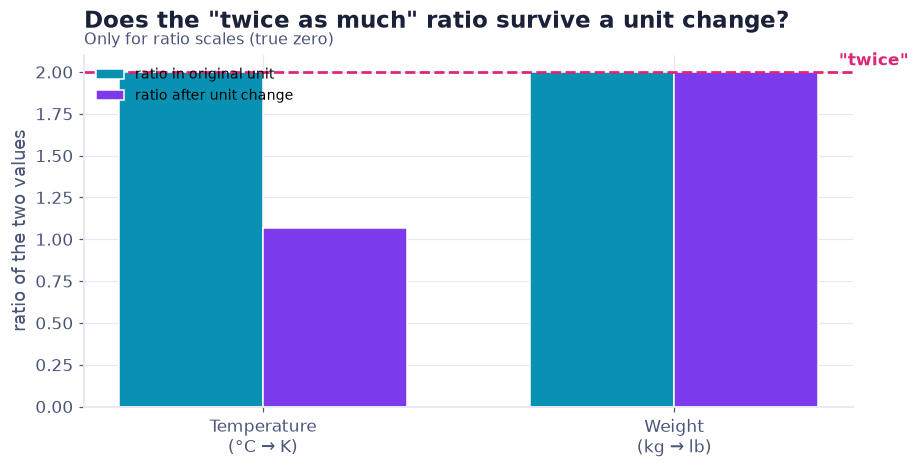

In [4]:
# Visualize: the "twice" ratio holds for weight but collapses for temperature
fig, ax = plt.subplots(figsize=(8.5,4.4))
groups = ["Temperature\n(°C → K)", "Weight\n(kg → lb)"]
orig   = [c2/c1, w2/w1]
conv   = [k2/k1, (w2*2.205)/(w1*2.205)]
x = np.arange(2); w = 0.35
ax.bar(x-w/2, orig, w, color=CYAN, label="ratio in original unit", edgecolor="white")
ax.bar(x+w/2, conv, w, color=PURPLE, label="ratio after unit change", edgecolor="white")
ax.axhline(2, color=PINK, ls="--", lw=1.8)
ax.text(1.4, 2.04, "\"twice\"", color=PINK, fontweight="bold")
titlecard(ax, "Does the \"twice as much\" ratio survive a unit change?", "Only for ratio scales (true zero)")
ax.set_xticks(x); ax.set_xticklabels(groups); ax.set_ylabel("ratio of the two values"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**The test:** does zero mean *"none of it"*? Weight: yes (0 kg = no mass) → **ratio**. Celsius: no (0°C is just freezing water) → **interval**. Only ratio scales support "twice / half / 3×" statements.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · THE RIGHT CENTER</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🎯 Mode, median, or mean?</div>
<div style="color:#4a5578;margin-top:6px">The level decides which average is valid: Nominal → mode, Ordinal → median, Interval/Ratio → mean.</div>
</div>

In [5]:
# NOMINAL: only the mode makes sense (you can't average "O" and "A")
blood = pd.Series(["O","A","O","B","O"])
print("Nominal  -> mode   :", blood.mode()[0])

# ORDINAL: median is safe; the MEAN of codes is misleading (gaps may be unequal)
sat = pd.Series([1, 5, 3, 5, 1])   # Low=1 ... High=5
print(f"Ordinal  -> median : {sat.median():.0f}    (mean {sat.mean():.1f} is misleading — gaps aren't equal)")

# RATIO: the mean is perfectly valid
weight = pd.Series([62, 81, 55, 90, 70])
print(f"Ratio    -> mean   : {weight.mean():.1f} kg")

Nominal  -> mode   : O
Ordinal  -> median : 3    (mean 3.0 is misleading — gaps aren't equal)
Ratio    -> mean   : 71.6 kg


**Watch out:** coding ordinal labels as 1–5 makes the *mean* computable but not meaningful, the distance from "Low" to "Medium" may not equal "Medium" to "High". Report the **median** instead.

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 4 · WHAT EACH LEVEL ALLOWS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">✅ A grid of permitted operations</div>
<div style="color:#4a5578;margin-top:6px">Each level unlocks one more operation. It's cumulative, ratio can do everything the others can, and more.</div>
</div>

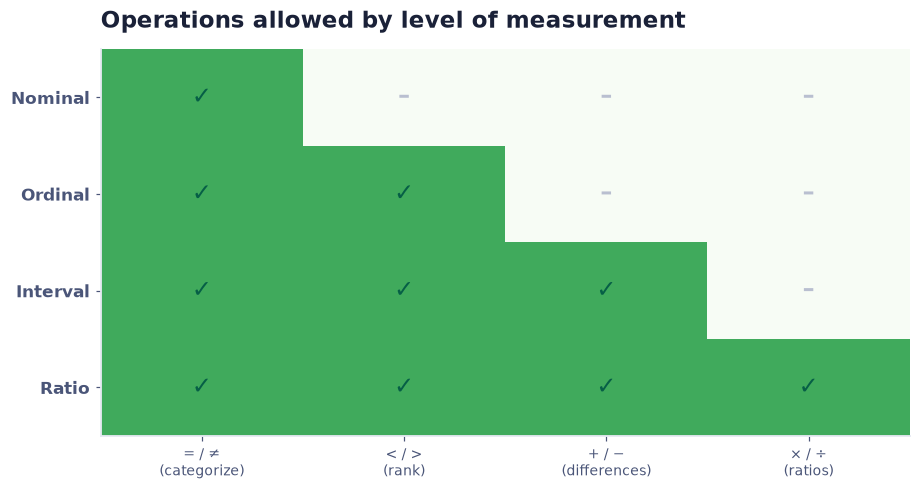

In [6]:
ops    = ["= / ≠\n(categorize)", "< / >\n(rank)", "+ / −\n(differences)", "× / ÷\n(ratios)"]
lvls   = ["Nominal","Ordinal","Interval","Ratio"]
allowed = np.array([[1,0,0,0],
                    [1,1,0,0],
                    [1,1,1,0],
                    [1,1,1,1]])

fig, ax = plt.subplots(figsize=(8.5,4.6))
ax.imshow(allowed, cmap="Greens", vmin=0, vmax=1.6, aspect="auto")
ax.set_xticks(range(4)); ax.set_xticklabels(ops, fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels(lvls, fontsize=11, fontweight="bold")
for i in range(4):
    for j in range(4):
        ax.text(j, i, "✓" if allowed[i,j] else "–",
                ha="center", va="center", fontsize=16,
                color="#065f46" if allowed[i,j] else "#b9bfd0", fontweight="bold")
ax.set_title("Operations allowed by level of measurement", loc="left", pad=14)
ax.grid(False)
plt.tight_layout(); plt.show()

Reading the staircase: as you climb Nominal → Ordinal → Interval → Ratio, each step keeps every earlier ability and **adds one more**.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>NOIR:</b> Nominal (labels) → Ordinal (order) → Interval (equal gaps) → Ratio (true zero).</li>
<li><b>Interval vs ratio</b> hinges on a <b>true zero</b>, only ratio scales support "twice as much".</li>
<li><b>Right center:</b> mode (nominal), median (ordinal), mean (interval/ratio).</li>
<li><b>Allowed operations are cumulative</b>, ratio can do everything; nominal only categorizes.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>